## 1. Persiapan Lingkungan

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install scikit-image -q
print("Install selesai - WAJIB: Klik Runtime > Restart Runtime sebelum lanjut!")

Install selesai - WAJIB: Klik Runtime > Restart Runtime sebelum lanjut!


## 2. Import Library

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import collections
import pickle
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

print("Semua library berhasil diimport")

Semua library berhasil diimport


## 3. Konfigurasi

In [4]:
DATA_DIR = "/content/drive/MyDrive/Dataset_Daun_Mangga"
IMG_SIZE = (256, 256)

# Hitung otomatis dari folder, bukan hardcode
DATASET_INFO = {}
for kelas in sorted(os.listdir(DATA_DIR)):
    kelas_dir = os.path.join(DATA_DIR, kelas)
    if os.path.isdir(kelas_dir):
        jumlah = len([f for f in os.listdir(kelas_dir)
                      if os.path.isfile(os.path.join(kelas_dir, f))])
        DATASET_INFO[kelas] = {"jumlah": jumlah}

print("Dataset ditemukan:")
total = 0
for kelas, info in DATASET_INFO.items():
    print(f"   {kelas:<20} : {info['jumlah']} gambar")
    total += info['jumlah']
print(f"\n   Total: {total} gambar")

Dataset ditemukan:
   Anthracnose          : 200 gambar
   Daun Sehat           : 200 gambar
   Die Back             : 200 gambar
   Gall Midge           : 200 gambar
   Powdery Mildew       : 200 gambar
   Sooty Mould          : 200 gambar

   Total: 1200 gambar


## 4. Visualisasi Distribusi Dataset

In [5]:
# ── Tabel informasi dataset ───────────────────────────────────────────────────
print("=" * 60)
print(f"{'No':<5} {'Kelas':<20} {'Jumlah':>8}")
print("=" * 60)
total = 0
for i, (kelas, info) in enumerate(DATASET_INFO.items(), 1):
    print(f"{i:<5} {kelas:<20} {info['jumlah']:>8}")
    total += info['jumlah']
print("-" * 60)
print(f"{'':5} {'Total':<20} {total:>8}")
print("=" * 60)

No    Kelas                  Jumlah
1     Anthracnose               200
2     Daun Sehat                200
3     Die Back                  200
4     Gall Midge                200
5     Powdery Mildew            200
6     Sooty Mould               200
------------------------------------------------------------
      Total                    1200


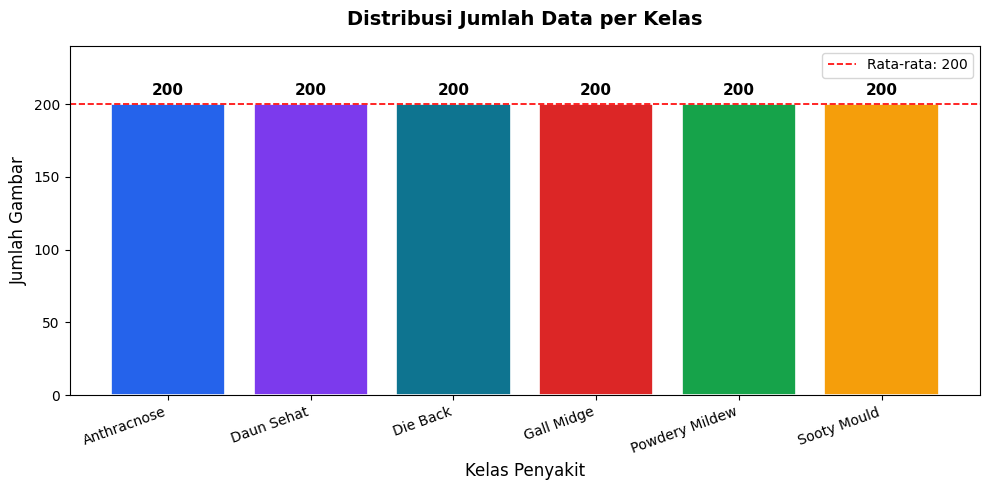

Grafik distribusi dataset tersimpan


In [6]:
# ── Bar chart distribusi dataset ──────────────────────────────────────────────
kelas_list  = list(DATASET_INFO.keys())
jumlah_list = [v["jumlah"] for v in DATASET_INFO.values()]
colors      = ["#2563eb","#7c3aed","#0e7490","#dc2626","#16a34a","#f59e0b"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(kelas_list, jumlah_list, color=colors, edgecolor="white", linewidth=1.2)

# Nilai di atas setiap bar
for bar, val in zip(bars, jumlah_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

# Garis rata-rata
avg = sum(jumlah_list) / len(jumlah_list)
ax.axhline(avg, color="red", linestyle="--", linewidth=1.2, label=f"Rata-rata: {avg:.0f}")

ax.set_title("Distribusi Jumlah Data per Kelas", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Kelas Penyakit", fontsize=12)
ax.set_ylabel("Jumlah Gambar", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(jumlah_list) + 40)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("distribusi_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik distribusi dataset tersimpan")

## 5. Ekstraksi Fitur GLCM

**Gray Level Co-occurrence Matrix (GLCM)** menganalisis hubungan antar piksel tetangga pada gambar grayscale.  
Empat fitur yang diekstrak:

| Fitur | Keterangan |
|---|---|
| **Contrast** | Mengukur variasi intensitas antar piksel tetangga |
| **Correlation** | Mengukur korelasi linear antar piksel |
| **Energy** | Mengukur keseragaman (uniformity) tekstur |
| **Homogeneity** | Mengukur kedekatam distribusi elemen terhadap diagonal GLCM |

Parameter GLCM: ,

In [7]:
def auto_crop_leaf(img):
    """
    Mendeteksi area daun (hijau/kecoklatan) dan crop background di sekitarnya.
    Fallback ke gambar asli jika deteksi gagal.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Range warna daun: hijau tua sampai coklat (mencakup daun sakit)
    lower = np.array([10, 30, 20])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)

    # Bersihkan noise kecil (rumput, bintik tanah)
    kernel = np.ones((21, 21), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area_ratio = cv2.contourArea(largest) / (img.shape[0] * img.shape[1])

        if area_ratio > 0.08:  # hanya crop kalau area cukup signifikan
            x, y, w, h = cv2.boundingRect(largest)
            pad = 25
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(img.shape[1], x + w + pad), min(img.shape[0], y + h + pad)
            return img[y1:y2, x1:x2]

    return img  # fallback: gambar asli kalau gagal deteksi

print("Fungsi auto_crop_leaf siap digunakan")

Fungsi auto_crop_leaf siap digunakan


In [8]:
def extract_combined_features(img):
    """
    Ekstraksi fitur gabungan: GLCM + Warna HSV
    Dengan auto-crop background sebelum ekstraksi.
    """
    img = auto_crop_leaf(img)   # ← TAMBAHAN PENTING: crop dulu
    img_resized = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray, distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256, symmetric=True, normed=True
    )
    contrast    = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy      = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    h_mean, h_std = h.mean(), h.std()
    s_mean, s_std = s.mean(), s.std()
    v_mean, v_std = v.mean(), v.std()

    return [contrast, correlation, energy, homogeneity,
            h_mean, h_std, s_mean, s_std, v_mean, v_std]

print("Fungsi ekstraksi fitur (dengan auto-crop) siap digunakan")

Fungsi ekstraksi fitur (dengan auto-crop) siap digunakan


## 6. Load Dataset & Ekstraksi Fitur

In [9]:
X          = []
y          = []
y_original = []

for label in sorted(os.listdir(DATA_DIR)):
    label_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(label_dir):
        continue

    count = 0
    for file in os.listdir(label_dir):
        file_path = os.path.join(label_dir, file)
        img = cv2.imread(file_path)
        if img is not None:
            features = extract_combined_features(img)   # ← GANTI di sini
            X.append(features)
            y.append(label)
            y_original.append(label)
            count += 1

    print(f"  ✔ {label:<20} : {count} gambar")

X = np.array(X)
y = np.array(y)

print(f"\nTotal data dimuat : {len(X)} gambar")
print(f"   Dimensi fitur     : {X.shape}")   # harusnya (1200, 20)

  ✔ Anthracnose          : 200 gambar
  ✔ Daun Sehat           : 200 gambar
  ✔ Die Back             : 200 gambar
  ✔ Gall Midge           : 200 gambar
  ✔ Powdery Mildew       : 200 gambar
  ✔ Sooty Mould          : 200 gambar

Total data dimuat : 1200 gambar
   Dimensi fitur     : (1200, 10)


In [10]:
feature_names  = ["Contrast", "Correlation", "Energy", "Homogeneity"]
unique_classes = sorted(set(y_original))

print(f"{'Kelas':<20} {'Contrast':>12} {'Correlation':>14} {'Energy':>12} {'Homogeneity':>14}")
print("=" * 75)
for kelas in unique_classes:
    idx = np.where(np.array(y_original) == kelas)[0]
    means = X[idx].mean(axis=0)
    print(f"{kelas:<20} {means[0]:>12.4f} {means[1]:>14.4f} {means[2]:>12.4f} {means[3]:>14.4f}")

Kelas                    Contrast    Correlation       Energy    Homogeneity
Anthracnose              213.6412         0.9717       0.0256         0.1910
Daun Sehat               201.4314         0.9779       0.0319         0.2891
Die Back                 198.9868         0.9706       0.0386         0.2650
Gall Midge               156.9634         0.9788       0.0261         0.2164
Powdery Mildew           193.4862         0.9701       0.0233         0.2010
Sooty Mould              337.5494         0.9700       0.0495         0.3156


## 7. Visualisasi Hasil Resize


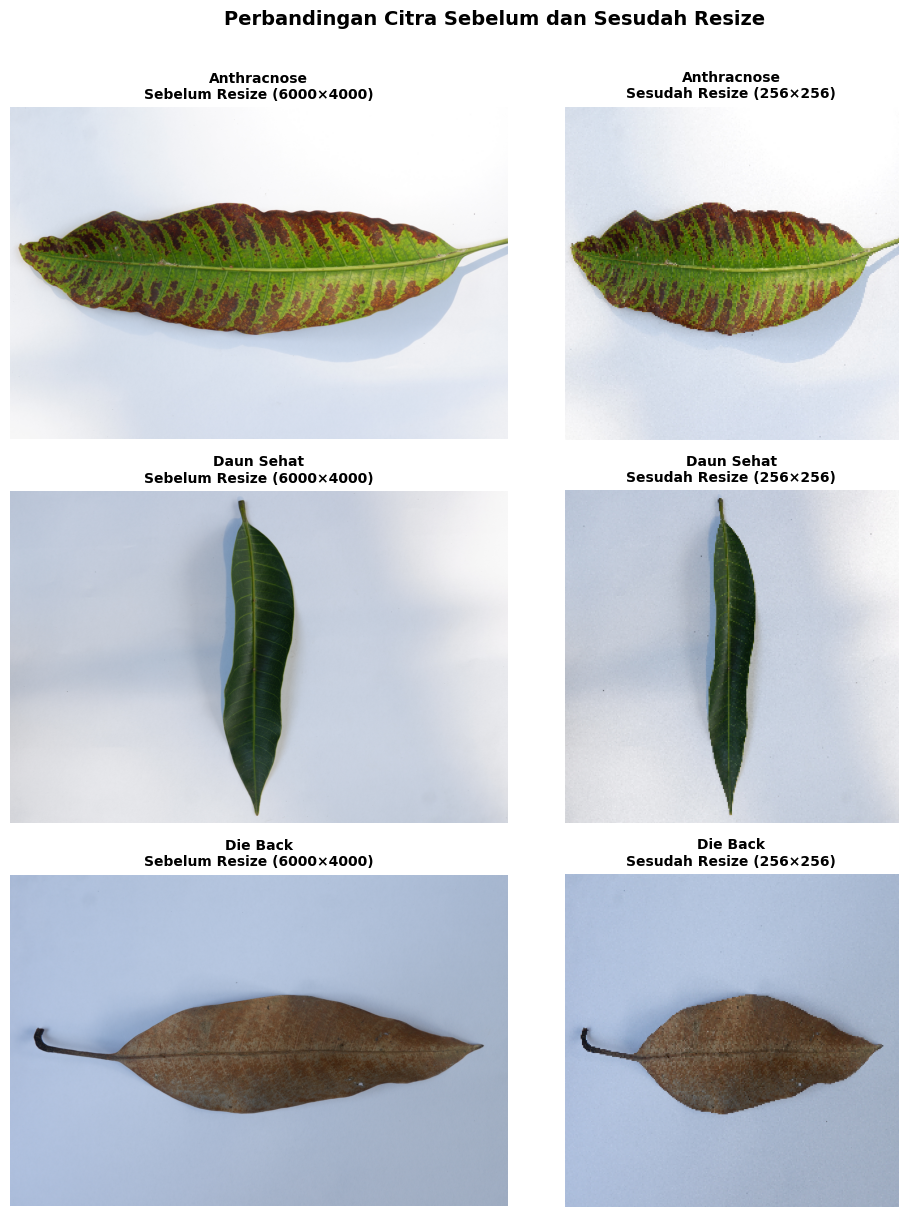

Gambar perbandingan resize tersimpan


In [11]:
# ── Visualisasi Perbandingan Sebelum dan Sesudah Resize ──────────────────────
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# Ambil 3 sampel dari kelas berbeda
sample_classes = []
for kelas in sorted(os.listdir(DATA_DIR)):
    kelas_dir = os.path.join(DATA_DIR, kelas)
    if os.path.isdir(kelas_dir):
        sample_classes.append(kelas)
    if len(sample_classes) == 3:
        break

for i, kelas in enumerate(sample_classes):
    kelas_dir = os.path.join(DATA_DIR, kelas)
    sample_file = os.listdir(kelas_dir)[0]
    img = cv2.imread(os.path.join(kelas_dir, sample_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    # Sebelum resize
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{kelas}\nSebelum Resize ({img_rgb.shape[1]}×{img_rgb.shape[0]})",
                         fontsize=10, fontweight="bold")
    axes[i, 0].axis("off")

    # Sesudah resize
    axes[i, 1].imshow(img_resized)
    axes[i, 1].set_title(f"{kelas}\nSesudah Resize (256×256)",
                         fontsize=10, fontweight="bold")
    axes[i, 1].axis("off")

fig.suptitle("Perbandingan Citra Sebelum dan Sesudah Resize",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("perbandingan_resize.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar perbandingan resize tersimpan")

## 8. Visualisasi RGB vs Grayscale per Kelas

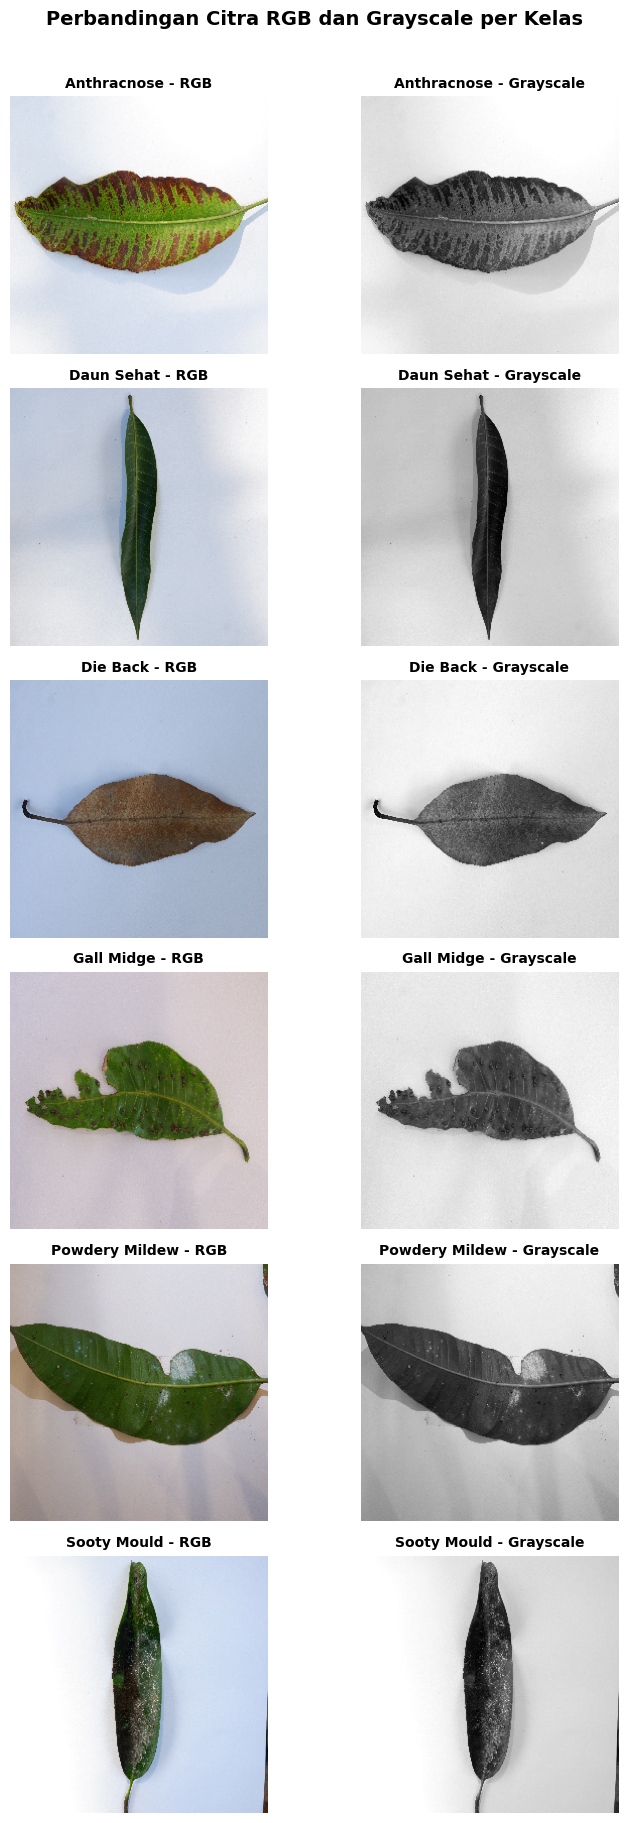

Gambar perbandingan RGB vs Grayscale tersimpan


In [12]:
# ── Visualisasi Perbandingan RGB vs Grayscale per Kelas ──────────────────────
kelas_list_dir = sorted([k for k in os.listdir(DATA_DIR)
                         if os.path.isdir(os.path.join(DATA_DIR, k))])

fig, axes = plt.subplots(len(kelas_list_dir), 2, figsize=(8, len(kelas_list_dir) * 3))

for i, kelas in enumerate(kelas_list_dir):
    kelas_dir = os.path.join(DATA_DIR, kelas)
    sample_file = os.listdir(kelas_dir)[0]
    img = cv2.imread(os.path.join(kelas_dir, sample_file))
    img_resized = cv2.resize(img, IMG_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # RGB
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{kelas} - RGB", fontsize=10, fontweight="bold")
    axes[i, 0].axis("off")

    # Grayscale
    axes[i, 1].imshow(img_gray, cmap="gray")
    axes[i, 1].set_title(f"{kelas} - Grayscale", fontsize=10, fontweight="bold")
    axes[i, 1].axis("off")

fig.suptitle("Perbandingan Citra RGB dan Grayscale per Kelas",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("perbandingan_rgb_grayscale.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar perbandingan RGB vs Grayscale tersimpan")

## 9. Visualisasi Nilai Rata-rata Fitur GLCM per Kelas

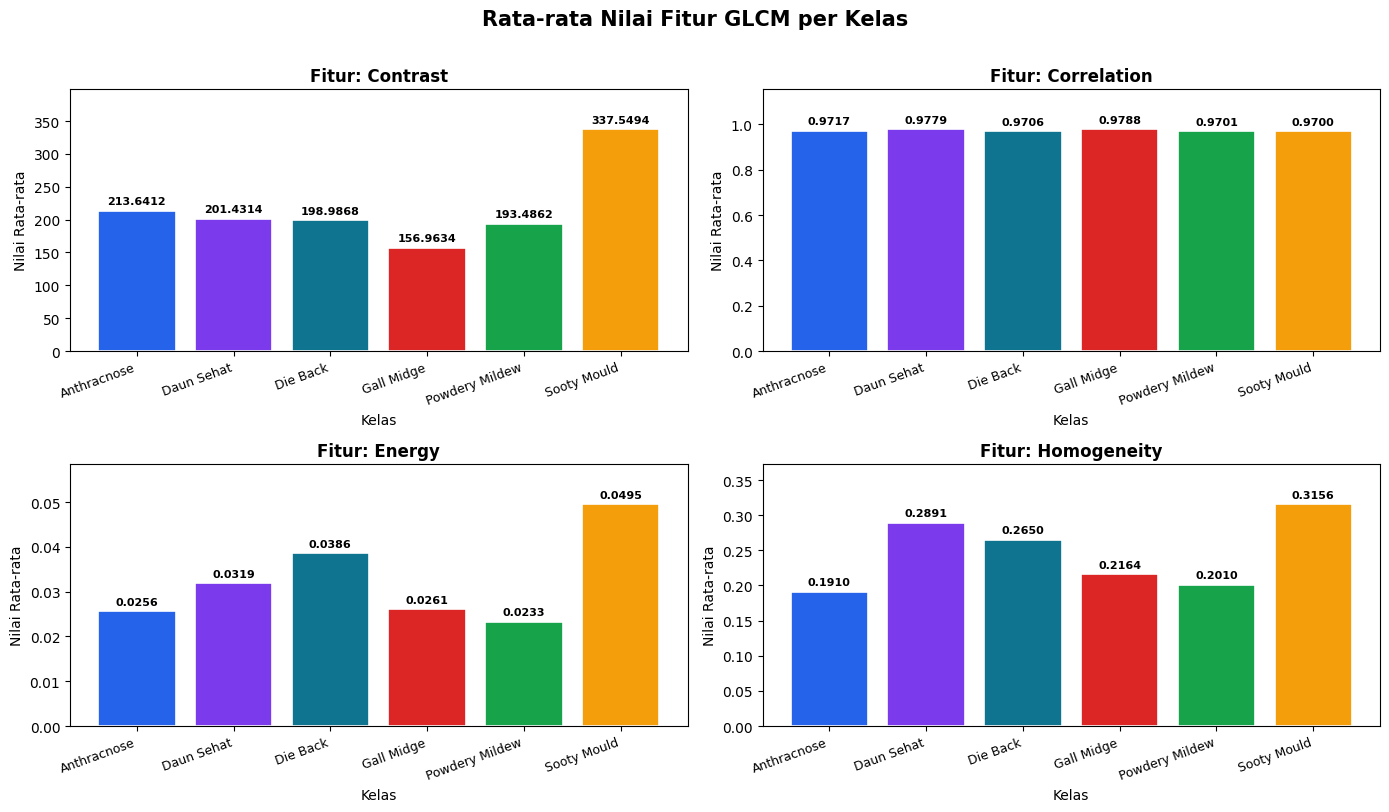

Grafik GLCM per kelas tersimpan


In [13]:
feature_names  = ["Contrast", "Correlation", "Energy", "Homogeneity"]
unique_classes = sorted(set(y_original))
colors         = ["#2563eb","#7c3aed","#0e7490","#dc2626","#16a34a","#f59e0b"]

class_means = {}
for kelas in unique_classes:
    idx = np.where(np.array(y_original) == kelas)[0]
    class_means[kelas] = X[idx].mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for f_idx, (feat, ax) in enumerate(zip(feature_names, axes)):
    values = [class_means[kelas][f_idx] for kelas in unique_classes]
    bars   = ax.bar(unique_classes, values,
                    color=colors, edgecolor="white", linewidth=1.2)

    # Nilai di atas bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.02,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

    ax.set_title(f"Fitur: {feat}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Kelas", fontsize=10)
    ax.set_ylabel("Nilai Rata-rata", fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)

fig.suptitle("Rata-rata Nilai Fitur GLCM per Kelas",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("glcm_per_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik GLCM per kelas tersimpan")

## 10. Label Encoding & Pembagian Dataset

In [14]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = le.classes_
print("Label Encoding selesai")
print(f"   Kelas : {list(class_names)}")
print(f"   Kode  : {list(range(len(class_names)))}")

# Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Pembagian dataset (80:20)")
print(f"Data latih  : {len(X_train)} sampel")
print(f"Data uji    : {len(X_test)}  sampel")

Label Encoding selesai
   Kelas : [np.str_('Anthracnose'), np.str_('Daun Sehat'), np.str_('Die Back'), np.str_('Gall Midge'), np.str_('Powdery Mildew'), np.str_('Sooty Mould')]
   Kode  : [0, 1, 2, 3, 4, 5]
Pembagian dataset (80:20)
Data latih  : 960 sampel
Data uji    : 240  sampel


## 11. Eksperimen Jumlah Estimator (n_estimators)

Percobaan ini menentukan jumlah pohon optimal pada Random Forest.

  n_estimators    Train Acc     Test Acc
------------------------------------------
            10      0.9990      1.0000
            20      1.0000      1.0000
            50      1.0000      1.0000
           100      1.0000      1.0000
           150      1.0000      1.0000
           200      1.0000      1.0000


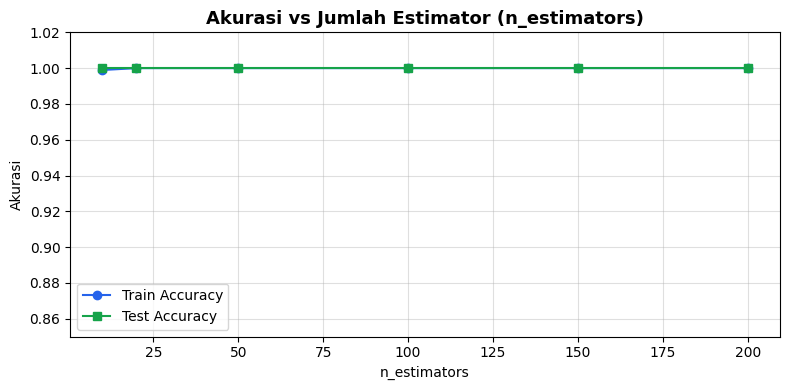

Grafik n_estimators tersimpan


In [15]:
n_range    = [10, 20, 50, 100, 150, 200]
train_accs = []
test_accs  = []

for n in n_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, rf_temp.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  rf_temp.predict(X_test)))

# Tabel hasil
print(f"{'n_estimators':>14} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 42)
for n, tr, te in zip(n_range, train_accs, test_accs):
    print(f"{n:>14} {tr:>11.4f} {te:>11.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_range, train_accs, marker="o", label="Train Accuracy", color="#2563eb")
ax.plot(n_range, test_accs,  marker="s", label="Test Accuracy",  color="#16a34a")
ax.set_title("Akurasi vs Jumlah Estimator (n_estimators)", fontsize=13, fontweight="bold")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Akurasi")
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("grafik_nestimators.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik n_estimators tersimpan")

## 12. Training Model Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1          # gunakan semua core CPU
)

rf_model.fit(X_train, y_train)

print("Model berhasil dilatih")
print(f"   Jumlah pohon     : {rf_model.n_estimators}")
print(f"   Jumlah fitur     : {rf_model.n_features_in_}")
print(f"   Jumlah kelas     : {rf_model.n_classes_}")

Model berhasil dilatih
   Jumlah pohon     : 100
   Jumlah fitur     : 10
   Jumlah kelas     : 6


## 13. Cross Validation (5-Fold)

Cross validation digunakan untuk mengevaluasi kestabilan model secara lebih robust.

Hasil Cross Validation (5-Fold Stratified):
   Fold 1 : 0.9958
   Fold 2 : 0.9958
   Fold 3 : 1.0000
   Fold 4 : 1.0000
   Fold 5 : 0.9958

   Rata-rata : 0.9975
   Std Dev   : 0.0020

   Model STABIL (std dev rendah)


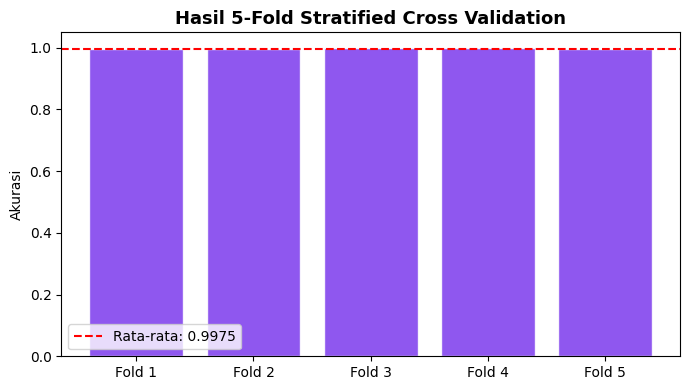

In [17]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X, y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Hasil Cross Validation (5-Fold Stratified):")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i} : {score:.4f}")
print(f"\n   Rata-rata : {cv_scores.mean():.4f}")
print(f"   Std Dev   : {cv_scores.std():.4f}")

if cv_scores.std() < 0.03:
    print("\n   Model STABIL (std dev rendah)")
elif cv_scores.std() < 0.05:
    print("\n   Model cukup stabil")
else:
    print("\n   Model TIDAK STABIL (std dev terlalu tinggi)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"Fold {i}" for i in range(1, 6)], cv_scores,
       color="#7c3aed", alpha=0.85, edgecolor="white")
ax.axhline(cv_scores.mean(), color="red", linestyle="--",
           label=f"Rata-rata: {cv_scores.mean():.4f}")
ax.set_title("Hasil 5-Fold Stratified Cross Validation", fontsize=13, fontweight="bold")
ax.set_ylabel("Akurasi")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Evaluasi Model

In [18]:
y_pred = rf_model.predict(X_test)

# ── Akurasi ────────────────────────────────────────────────────────────────────
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print("=" * 45)
print(f"  Akurasi Data Latih  : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Akurasi Data Uji    : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Selisih (gap)       : {abs(train_acc - test_acc):.4f}")
print("=" * 45)

if abs(train_acc - test_acc) < 0.05:
    print("Model tergolong NORMAL (tidak over/underfitting)")
elif train_acc - test_acc > 0.10:
    print("Kemungkinan OVERFITTING (gap terlalu besar)")
else:
    print("Perlu diperiksa lebih lanjut")

  Akurasi Data Latih  : 1.0000 (100.00%)
  Akurasi Data Uji    : 1.0000  (100.00%)
  Selisih (gap)       : 0.0000
Model tergolong NORMAL (tidak over/underfitting)


In [19]:
# ── Classification Report ──────────────────────────────────────────────────────
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:
                precision    recall  f1-score   support

   Anthracnose       1.00      1.00      1.00        40
    Daun Sehat       1.00      1.00      1.00        40
      Die Back       1.00      1.00      1.00        40
    Gall Midge       1.00      1.00      1.00        40
Powdery Mildew       1.00      1.00      1.00        40
   Sooty Mould       1.00      1.00      1.00        40

      accuracy                           1.00       240
     macro avg       1.00      1.00      1.00       240
  weighted avg       1.00      1.00      1.00       240



## 15. Confusion Matrix

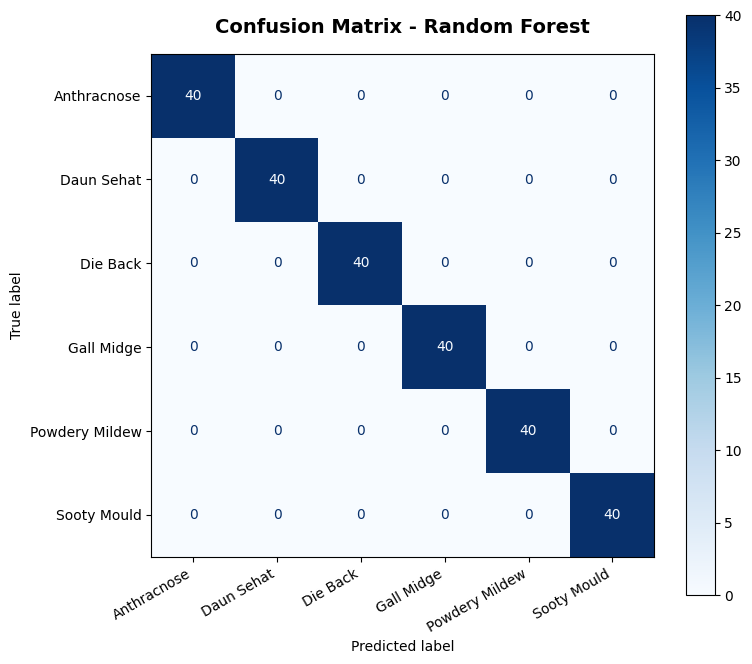

Confusion matrix tersimpan


In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=True)

ax.set_title("Confusion Matrix - Random Forest", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix tersimpan")

## 16. Feature Importance

Menunjukkan kontribusi setiap fitur GLCM terhadap keputusan klasifikasi model.

Total fitur: 10

📋 Feature Importance (Top 20):
---------------------------------------------
  HSV_H_Mean         0.1889  ██████████████████
  GLCM_Homogeneity   0.1509  ███████████████
  HSV_H_Std          0.1274  ████████████
  HSV_V_Std          0.1056  ██████████
  GLCM_Energy        0.0879  ████████
  HSV_S_Mean         0.0764  ███████
  HSV_S_Std          0.0761  ███████
  GLCM_Correlation   0.0641  ██████
  GLCM_Contrast      0.0639  ██████
  HSV_V_Mean         0.0589  █████


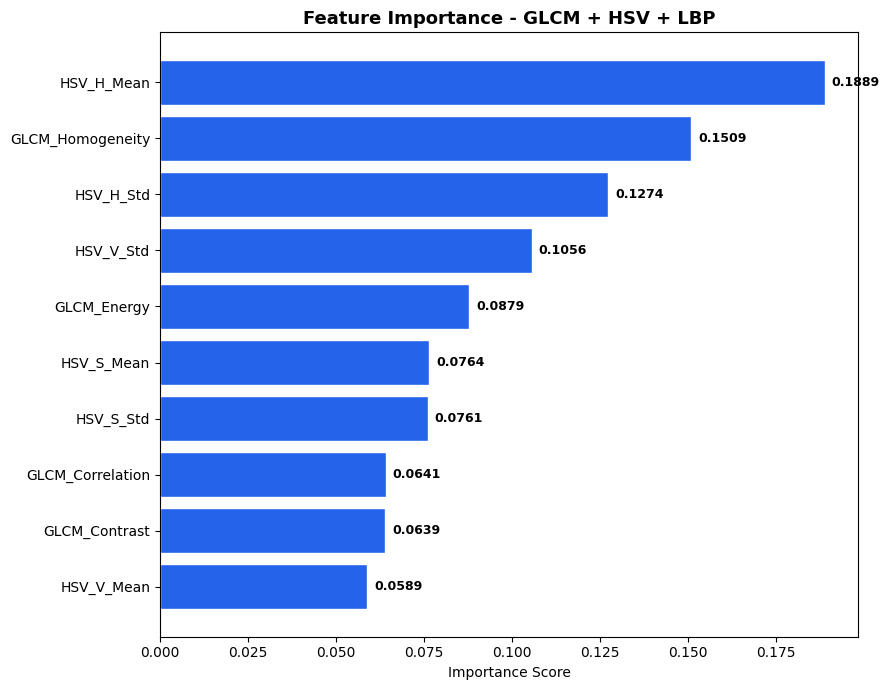


📊 Grafik feature importance tersimpan


In [21]:
feature_names = [
    "GLCM_Contrast", "GLCM_Correlation", "GLCM_Energy", "GLCM_Homogeneity",
    "HSV_H_Mean", "HSV_H_Std", "HSV_S_Mean", "HSV_S_Std", "HSV_V_Mean", "HSV_V_Std"
]
print(f"Total fitur: {len(feature_names)}")

# ===== Ambil feature importance dari model =====
importances = rf_model.feature_importances_

# Urutkan dari terbesar
sorted_idx  = np.argsort(importances)[::-1]
sorted_feat = [feature_names[i] for i in sorted_idx]
sorted_imp  = importances[sorted_idx]

print("\n📋 Feature Importance (Top 20):")
print("-" * 45)
for feat, imp in zip(sorted_feat, sorted_imp):
    bar = "█" * int(imp * 100)
    print(f"  {feat:<18} {imp:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(sorted_feat, sorted_imp, color="#2563eb", edgecolor="white")

for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

ax.set_title("Feature Importance - GLCM + HSV + LBP", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Grafik feature importance tersimpan")

## 17. Ringkasan Hasil Evaluasi

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test,    y_pred, average="weighted")
f1        = f1_score(y_test,        y_pred, average="weighted")

print("╔══════════════════════════════════════════╗")
print("║        RINGKASAN EVALUASI MODEL          ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Model          : Random Forest          ║")
print(f"║  Fitur          : GLCM (4 fitur)         ║")
print(f"║  n_estimators   : 100                    ║")
print(f"║  Split          : 80% train / 20% test   ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Akurasi        : {test_acc*100:>6.2f}%                ║")
print(f"║  Precision (w)  : {precision*100:>6.2f}%                ║")
print(f"║  Recall    (w)  : {recall*100:>6.2f}%                ║")
print(f"║  F1-Score  (w)  : {f1*100:>6.2f}%                ║")
print(f"║  CV Score (5-fold): {cv_scores.mean()*100:>5.2f}%               ║")
print("╚══════════════════════════════════════════╝")

╔══════════════════════════════════════════╗
║        RINGKASAN EVALUASI MODEL          ║
╠══════════════════════════════════════════╣
║  Model          : Random Forest          ║
║  Fitur          : GLCM (4 fitur)         ║
║  n_estimators   : 100                    ║
║  Split          : 80% train / 20% test   ║
╠══════════════════════════════════════════╣
║  Akurasi        : 100.00%                ║
║  Precision (w)  : 100.00%                ║
║  Recall    (w)  : 100.00%                ║
║  F1-Score  (w)  : 100.00%                ║
║  CV Score (5-fold): 99.75%               ║
╚══════════════════════════════════════════╝


In [23]:
def predict_image_rf(img_path, model, le):
    """
    Prediksi kelas penyakit daun mangga dari satu gambar.
    Input : path gambar, model RF, label encoder
    Output: (label, confidence %)
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"Gambar tidak ditemukan: {img_path}")
        return None

    features  = extract_glcm_features(img)
    features  = np.array(features).reshape(1, -1)

    pred       = model.predict(features)
    label      = le.inverse_transform(pred)[0]
    proba      = model.predict_proba(features)[0]
    confidence = np.max(proba) * 100

    # Tampilkan semua probabilitas
    print("Probabilitas per Kelas:")
    for cls, prob in zip(le.classes_, proba):
        bar = "█" * int(prob * 30)
        print(f"   {cls:<20} {prob*100:>6.2f}%  {bar}")

    return label, confidence

print("Fungsi prediksi siap digunakan")

Fungsi prediksi siap digunakan


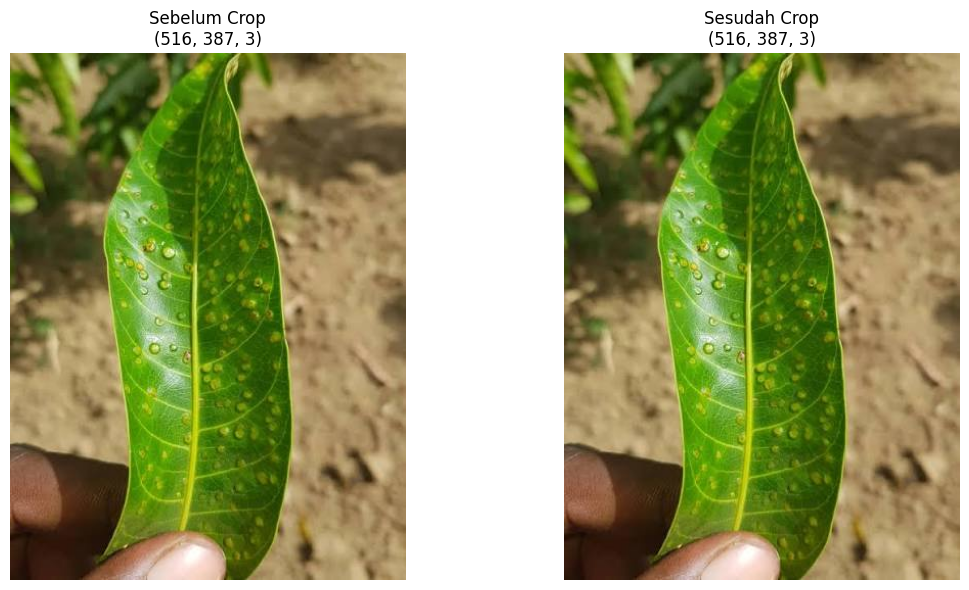

In [26]:
import matplotlib.pyplot as plt

test_path = "/content/drive/MyDrive/Dataset_Daun_Mangga/gall-midge.jpeg"
img_original = cv2.imread(test_path)
img_cropped = auto_crop_leaf(img_original)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Sebelum Crop\n{img_original.shape}")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Sesudah Crop\n{img_cropped.shape}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 19. Simpan Model

In [ ]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model berhasil disimpan:")
print("   - rf_model.pkl")
print("   - label_encoder.pkl")

from google.colab import files
files.download('rf_model.pkl')
files.download('label_encoder.pkl')